In [140]:
import pandas as pd
import numpy as np

In [141]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [142]:
dataset=pd.read_csv('/content/drive/MyDrive/project/laptop_data.csv')

In [143]:
dataset.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [144]:
dataset.shape

(1303, 12)

In [145]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [146]:
dataset.duplicated().sum()

np.int64(0)

In [147]:
dataset.isnull().sum()

,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


In [148]:
dataset.drop(columns=['Unnamed: 0'],inplace=True)

In [149]:
dataset['Ram']=dataset['Ram'].str.replace('GB','')
dataset['Weight']=dataset['Weight'].str.replace('kg','')

In [150]:
dataset.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [151]:
dataset['Ram']=dataset['Ram'].astype('int32')
dataset['Weight']=dataset['Weight'].astype('float32')

In [152]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 101.9+ KB


In [153]:
import seaborn as sns

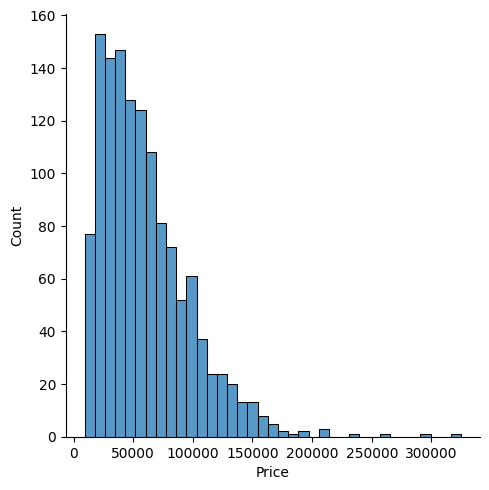

In [154]:
sns.displot(dataset['Price'])

<Axes: xlabel='Company'>

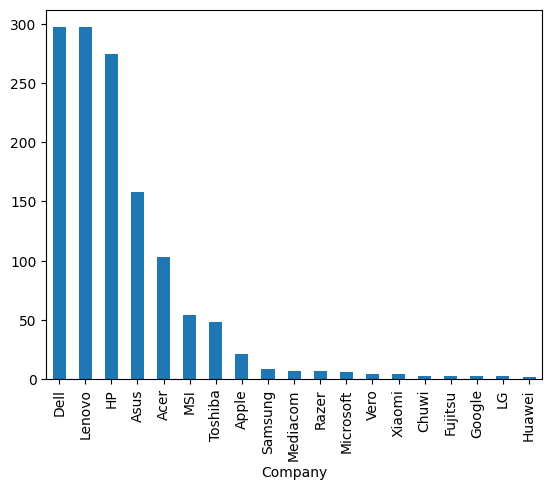

In [155]:
dataset['Company'].value_counts().plot(kind='bar')

In [156]:
new=dataset['ScreenResolution'].str.split('x',n=1,expand=True)

In [157]:
dataset['X_res']=new[0]
dataset['Y_res']=new[1]

In [158]:
dataset.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Full HD 1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,IPS Panel Retina Display 2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,IPS Panel Retina Display 2560,1600


In [159]:
dataset['X_res']=dataset['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [160]:
dataset.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560,1600


In [161]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
 11  X_res             1303 non-null   object 
 12  Y_res             1303 non-null   object 
dtypes: float32(1), float64(2), int32(1), object(9)
memory usage: 122.3+ KB


In [162]:
dataset['X_res']=dataset['X_res'].astype('int')
dataset['Y_res']=dataset['Y_res'].astype('int')

In [163]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
 11  X_res             1303 non-null   int64  
 12  Y_res             1303 non-null   int64  
dtypes: float32(1), float64(2), int32(1), int64(2), object(7)
memory usage: 122.3+ KB


In [164]:
dataset.corr(numeric_only=True)['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
X_res,0.556529
Y_res,0.552809


In [165]:
dataset['ppi']=(((dataset['X_res']**2) + (dataset['X_res']**2))**0.5/dataset['Inches']).astype(float)

In [166]:
dataset.corr(numeric_only=True)['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
X_res,0.556529
Y_res,0.552809
ppi,0.474973


In [167]:
dataset.drop(columns=['ScreenResolution'],inplace=True)

In [168]:
dataset.drop(columns=['Inches','X_res','Y_res'],inplace=True)

In [169]:
dataset.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,272.209528
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,153.117859
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,174.057054
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,264.476303
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,272.209528


In [170]:
dataset['Cpu Name']=dataset['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [171]:
def fetch_processor(text):
  if text== 'Intel Core i7' or text== 'Intel Core i5' or text== 'Intel Core i3':
    return text
  else:
    if text.split()[0] == 'Intel':
      return 'Other Intel Processor'
    else:
        return 'AMD Processor'

In [172]:
dataset['Cpu brand']=dataset['Cpu Name'].apply(fetch_processor)
dataset.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ppi,Cpu Name,Cpu brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,272.209528,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,153.117859,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,174.057054,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,264.476303,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,272.209528,Intel Core i5,Intel Core i5


In [173]:
import matplotlib.pyplot as plt

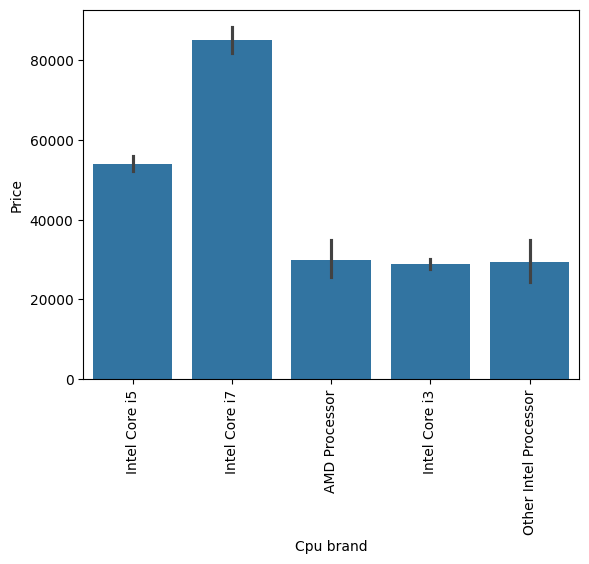

In [174]:
sns.barplot(x=dataset['Cpu brand'],y=dataset['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [175]:
dataset.drop(columns=['Cpu','Cpu Name',],inplace=True)

In [176]:
dataset.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,ppi,Cpu brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,272.209528,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,153.117859,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,174.057054,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,264.476303,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,272.209528,Intel Core i5


In [177]:
import pandas as pd

# Assuming 'dataset' is your DataFrame

# Remove '.0' from the 'Memory' column
dataset['Memory'] = dataset['Memory'].astype(str).replace('\.0', '', regex=True)

# Remove 'GB' and replace 'TB' with '000'
dataset['Memory'] = dataset['Memory'].str.replace('GB','').str.replace('TB','000')

# Split the 'Memory' column into 'first' and 'second' parts
new = dataset['Memory'].str.split("+", n=1, expand=True)

# Extract storage type information from the 'first' part
dataset['Layer1HDD'] = new[0].str.contains('HDD').astype(int)
dataset['Layer1SSD'] = new[0].str.contains('SSD').astype(int)
dataset['Layer1Hybrid'] = new[0].str.contains('Hybrid').astype(int)
dataset['Layer1Flash_Storage'] = new[0].str.contains('Flash Storage').astype(int)

# Extract numeric size from the 'first' part
dataset['first'] = new[0].str.extract('(\d+)').astype(float)

# Handle cases where the 'second' part is missing
new[1].fillna("0", inplace=True)

# Extract storage type information from the 'second' part
dataset['Layer2HDD'] = new[1].str.contains('HDD').astype(int)
dataset['Layer2SSD'] = new[1].str.contains('SSD').astype(int)
dataset['Layer2Hybrid'] = new[1].str.contains('Hybrid').astype(int)
dataset['Layer2Flash_Storage'] = new[1].str.contains('Flash Storage').astype(int)

# Extract numeric size from the 'second' part
dataset['second'] = new[1].str.extract('(\d+)').astype(float)

# Calculate total storage for each type
dataset['HDD'] = dataset['first'] * dataset['Layer1HDD'] + dataset['second'] * dataset['Layer2HDD']
dataset['SSD'] = dataset['first'] * dataset['Layer1SSD'] + dataset['second'] * dataset['Layer2SSD']
dataset['Hybrid'] = dataset['first'] * dataset['Layer1Hybrid'] + dataset['second'] * dataset['Layer2Hybrid']
dataset['Flash_Storage'] = dataset['first'] * dataset['Layer1Flash_Storage'] + dataset['second'] * dataset['Layer2Flash_Storage']

# Drop intermediate columns
dataset.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
                      'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid', 'Layer2Flash_Storage'], inplace=True)


<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1889074093.py:6: SyntaxWarning: invalid escape sequence '\.'
  dataset['Memory'] = dataset['Memory'].astype(str).replace('\.0', '', regex=True)
/tmp/ipython-input-1889074093.py:21: SyntaxWarning: invalid escape sequence '\d'
  dataset['first'] = new[0].str.extract('(\d+)').astype(float)
/tmp/ipython-input-1889074093.py:33: SyntaxWarning: invalid escape sequence '\d'
  dataset['second'] = new[1].str.extract('(\d+)').astype(float)
/tmp/ipython-input-1889074093.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work b

In [178]:
dataset.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,272.209528,Intel Core i5,0.0,128.0,0.0,0.0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,153.117859,Intel Core i5,0.0,0.0,0.0,128.0
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,174.057054,Intel Core i5,0.0,256.0,0.0,0.0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,264.476303,Intel Core i7,0.0,512.0,0.0,0.0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,272.209528,Intel Core i5,0.0,256.0,0.0,0.0


In [179]:
dataset.drop(columns=['Memory'],inplace=True)
dataset.drop(columns=['Hybrid','Flash_Storage'],inplace=True)
dataset.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,ppi,Cpu brand,HDD,SSD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,272.209528,Intel Core i5,0.0,128.0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,153.117859,Intel Core i5,0.0,0.0
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,174.057054,Intel Core i5,0.0,256.0
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,264.476303,Intel Core i7,0.0,512.0
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,272.209528,Intel Core i5,0.0,256.0


In [180]:
dataset['Gpu brand']=dataset['Gpu'].apply(lambda x:x.split()[0])
dataset['Gpu brand'].value_counts()

,count
Gpu brand,
Intel,722
Nvidia,400
AMD,180
ARM,1


In [181]:
dataset=dataset[dataset['Gpu brand'] !='ARM']
dataset.drop(columns=['Gpu'],inplace=True)

In [182]:
def cat_os(inp):
  if inp== 'Windows 10' or inp== 'Windows 7' or inp== 'Windows 10 S':
    return 'Windows'
  else:
    if inp== 'macOS' or 'Mac OS X':
      return 'Mac'
    else:
        return 'Others/No OS/Linux'

<Axes: >

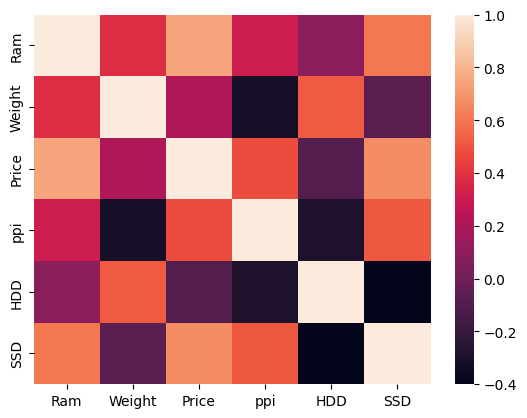

In [183]:
dataset['os']=dataset['OpSys'].apply(cat_os)
dataset.drop(columns=['OpSys'],inplace=True)
sns.heatmap(dataset.corr(numeric_only=True))

/tmp/ipython-input-823471553.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(dataset['Price']))


<Axes: xlabel='Price', ylabel='Density'>

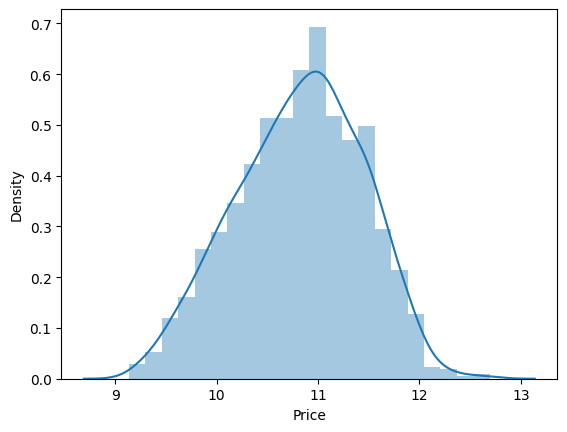

In [184]:
sns.distplot(np.log(dataset['Price']))

In [185]:
X=dataset.drop(columns=['Price'])
y=np.log(dataset['Price'])

In [186]:
X

,Company,TypeName,Ram,Weight,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,1.37,272.209528,Intel Core i5,0.0,128.0,Intel,Mac
1,Apple,Ultrabook,8,1.34,153.117859,Intel Core i5,0.0,0.0,Intel,Mac
2,HP,Notebook,8,1.86,174.057054,Intel Core i5,0.0,256.0,Intel,Mac
3,Apple,Ultrabook,16,1.83,264.476303,Intel Core i7,0.0,512.0,AMD,Mac
4,Apple,Ultrabook,8,1.37,272.209528,Intel Core i5,0.0,256.0,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,1.80,193.949289,Intel Core i7,0.0,128.0,Intel,Windows
1299,Lenovo,2 in 1 Convertible,16,1.30,340.261910,Intel Core i7,0.0,512.0,Intel,Windows
1300,Lenovo,Notebook,2,1.50,137.986838,Other Intel Processor,0.0,0.0,Intel,Windows
1301,HP,Notebook,6,2.19,123.834341,Intel Core i7,1000.0,0.0,AMD,Windows


In [187]:
y

,Price
0,11.175755
1,10.776777
2,10.329931
3,11.814476
4,11.473101
...,...
1298,10.433899
1299,11.288115
1300,9.409283
1301,10.614129


In [188]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.15,random_state=2)

In [189]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [190]:
step1=ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,5,8,9])
],remainder='passthrough')

step2=LinearRegression()

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8076272030239184
MAE 0.20995739979159198


In [191]:
np.exp(0.21)

np.float64(1.2336780599567432)

In [192]:
dataset.head(1)

,Company,TypeName,Ram,Weight,Price,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,272.209528,Intel Core i5,0.0,128.0,Intel,Mac


In [193]:
step1=ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,5,8,9])
],remainder='passthrough')

step2=Ridge(alpha=10)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8142956093694347
MAE 0.2094501865201661


In [194]:
step1=ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,5,8,9])
],remainder='passthrough')

step2=Ridge(alpha=0.001)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8076316141226787
MAE 0.20995622645443252


In [195]:
#Random Forest
step1=ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,5,8,9])
],remainder='passthrough')

step2=RandomForestRegressor(n_estimators=100,
                            random_state=3,
                            max_samples=0.5,
                            max_features=0.75,
                            max_depth=15)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.881769735468681
MAE 0.16476819685404118


In [196]:
import pickle
pickle.dump(dataset,open('dataset.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))

In [197]:
X_train

,Company,TypeName,Ram,Weight,ppi,Cpu brand,HDD,SSD,Gpu brand,os
183,Toshiba,Notebook,8,2.00,123.834341,Intel Core i5,0.0,128.0,Intel,Windows
1141,MSI,Gaming,8,2.40,174.057054,Intel Core i7,1000.0,128.0,Nvidia,Windows
1049,Asus,Netbook,4,1.20,166.535838,Other Intel Processor,0.0,0.0,Intel,Mac
1020,Dell,2 in 1 Convertible,4,2.08,174.057054,Intel Core i3,1000.0,0.0,Intel,Windows
878,Dell,Notebook,4,2.18,174.057054,Intel Core i5,1000.0,128.0,Nvidia,Windows
...,...,...,...,...,...,...,...,...,...,...
466,Acer,Notebook,4,2.20,123.834341,Intel Core i3,500.0,0.0,Nvidia,Windows
299,Asus,Ultrabook,16,1.63,174.057054,Intel Core i7,0.0,512.0,Nvidia,Windows
493,Acer,Notebook,8,2.20,123.834341,AMD Processor,1000.0,0.0,AMD,Windows
527,Lenovo,Notebook,8,2.20,123.834341,Intel Core i3,2000.0,0.0,Nvidia,Mac


In [206]:
!pip install streamlit

In [199]:
!pip install pyngrok

In [209]:
%%writefile myapp.py
import streamlit as st
import pickle
import numpy as np
import pandas as pd  # Add this import for dataset loading

pipe = pickle.load(open('pipe.pkl', 'rb'))


with open('dataset.pkl', 'rb') as file:
    dataset = pickle.load(file)

st.title("Laptop Price Predictor")

Company = st.selectbox('Brand', dataset['Company'].unique())
type = st.selectbox('Type', dataset['TypeName'].unique())
ram = st.selectbox('RAM(in GB)', [2, 4, 6, 8, 12, 16, 24])
weight = st.number_input('Weight of the laptop')
screen_size = st.number_input('Screen Size')
resolution = st.selectbox('Screen Resolution', ['1920x1080', '1366x768', '1600x900', '3840x2160', '3200x1800', '2880x1800', '2560x1600', '2560x1440', '2304x1440'])
cpu = st.selectbox('CPU', dataset['Cpu brand'].unique())
hdd = st.selectbox('HDD(in GB)', [0, 128, 256, 512, 1024])
ssd = st.selectbox('SSD(in GB)', [0, 8, 128, 256, 512, 1024])
gpu = st.selectbox('GPU', dataset['Gpu brand'].unique())
os = st.selectbox('OS', dataset['os'].unique())

if st.button('Predict Price'):
    ppi = None
    X_res = int(resolution.split('x')[0])
    Y_res = int(resolution.split('x')[1])
    ppi = ((X_res**2) + (Y_res**2))**0.5 / screen_size
    query = np.array([Company, type, ram, weight,screen_size, cpu, hdd, ssd, gpu, os])

    query = query.reshape(1, 10)
    st.title("The predicted Price of this configuration is " + str(int(np.exp(pipe.predict(query)[0]))))


Overwriting myapp.py


In [210]:
!pkill streamlit

In [211]:
!wget -q -O - ipv4.icanhazip.com

34.80.226.15


In [212]:
!streamlit run myapp.py --server.fileWatcherType none & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.80.226.15:8501

your url is: https://rare-bananas-learn.loca.lt
  Stopping...
^C
